# Logistic Regression : Student Admission Prediction

Is a student **Admitted (1)** or **Not Admitted (0)** based on their **GPA** and **Exam Score**?

This notebook covers:
1. Theory of Logistic Regression
2. Exploratory Data Analysis (EDA)
3. Train-Test Split
4. Model Training
5. Confusion Matrix, Accuracy, Precision, Recall

## 1. What is Logistic Regression?

Logistic Regression is used when the output (`y`) is **categorical** - here, 0 or 1 (Not Admitted / Admitted).

It is NOT like Linear Regression (which predicts continuous numbers). Instead, it predicts a **probability** between 0 and 1.

### Step 1: Linear part (same as Linear Regression)

For one input variable (single feature):

$$z = mx + c$$

For **multiple** input variables (our case: GPA and Exam Score), it becomes:

$$z = m_1x_1 + m_2x_2 + c$$

Here:
- $x_1$ = GPA
- $x_2$ = Exam Score
- $m_1, m_2$ = slopes (weights) for each feature
- $c$ = intercept (bias)

### Step 2: Sigmoid function

The value of `z` can be any number (negative, positive, big, small). We need a number between **0 and 1** (a probability). So we pass `z` through the **Sigmoid function**:

$$h = \frac{1}{1 + e^{-z}}$$

Substituting `z`:

$$h = \frac{1}{1 + e^{-(m_1x_1 + m_2x_2 + c)}}$$

- If $h \geq 0.5$ -> predict **1 (Admitted)**
- If $h < 0.5$ -> predict **0 (Not Admitted)**

### Why sigmoid? (Intuition, not math-heavy)

The sigmoid curve is S-shaped:
- Very negative `z` -> `h` close to 0
- Very positive `z` -> `h` close to 1
- `z = 0` -> `h = 0.5` (the decision boundary)

Let's actually plot this curve below to build intuition.

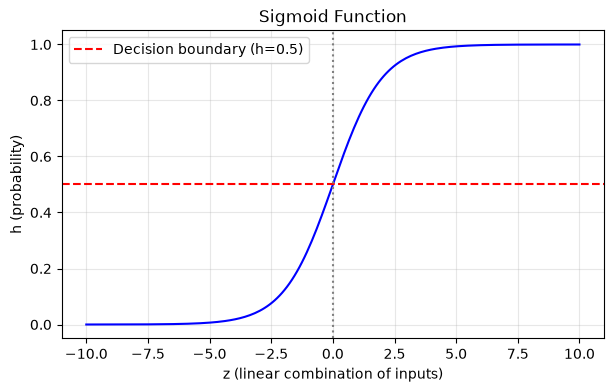

In [2]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-10, 10, 200)
h = 1 / (1 + np.exp(-z))

plt.figure(figsize=(7,4))
plt.plot(z, h, color='blue')
plt.axhline(0.5, color='red', linestyle='--', label='Decision boundary (h=0.5)')
plt.axvline(0, color='gray', linestyle=':')
plt.xlabel('z (linear combination of inputs)')
plt.ylabel('h (probability)')
plt.title('Sigmoid Function')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2. How does the algorithm find $m_1$, $m_2$, and $c$?

In simple Linear Regression, we can sometimes find slope and intercept using a direct formula.

In Logistic Regression, there is **no such direct formula**. The algorithm finds the best $m_1$, $m_2$, $c$ using an **iterative optimization process** called **Gradient Descent**, guided by a loss function called **Log Loss (Binary Cross-Entropy)**.

In short, here's what happens internally (no manual calculation needed - `sklearn` does this for us):

1. Start with random values of $m_1$, $m_2$, $c$.
2. Calculate predicted probability `h` for every row.
3. Compare `h` with actual `y` using the Log Loss function - this tells "how wrong" the model is.
4. Adjust $m_1$, $m_2$, $c$ slightly in the direction that reduces the error (this is Gradient Descent).
5. Repeat steps 2-4 many times (iterations) until the error stops reducing much.

**Important note for students:** Unlike simple Linear Regression, this multivariate slope-finding is *not* something we solve by hand with pen and paper in a normal classroom setting, it involves calculus (partial derivatives) applied repeatedly. It absolutely *can* be calculated manually if needed (that's exactly what the algorithm is doing internally, step by step), but for practical purposes we let the algorithm (`sklearn.linear_model.LogisticRegression`) do this automatically for us.

After training, `sklearn` directly gives us the final learned values:
- `model.coef_` -> gives $m_1$, $m_2$ (slopes for GPA and Exam Score)
- `model.intercept_` -> gives $c$

## 3. Load the Dataset

In [3]:
import pandas as pd

df = pd.read_csv('student_admission_data.csv')
df.head(10)

,GPA,Exam_Score,Result
0,2.75,32.0,0
1,3.90,75.0,1
2,3.46,52.0,0
3,3.20,66.0,1
4,2.31,94.0,0
5,2.31,47.0,0
6,2.12,59.0,0
7,3.73,83.0,1
8,3.20,46.0,0
9,3.42,35.0,0


In [4]:
df.shape

(100, 3)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   GPA         100 non-null    float64
 1   Exam_Score  100 non-null    float64
 2   Result      100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [6]:
df.describe()

,GPA,Exam_Score,Result
count,100.000000,100.000000,100.000000
mean,2.940200,64.850000,0.360000
std,0.594857,20.511822,0.482418
min,2.010000,30.000000,0.000000
25%,2.385000,47.000000,0.000000
50%,2.925000,65.500000,0.000000
75%,3.460000,83.500000,1.000000
max,3.970000,99.000000,1.000000


## 4. Exploratory Data Analysis (EDA)

In [7]:
df['Result'].value_counts()

Result
0    64
1    36
Name: count, dtype: int64

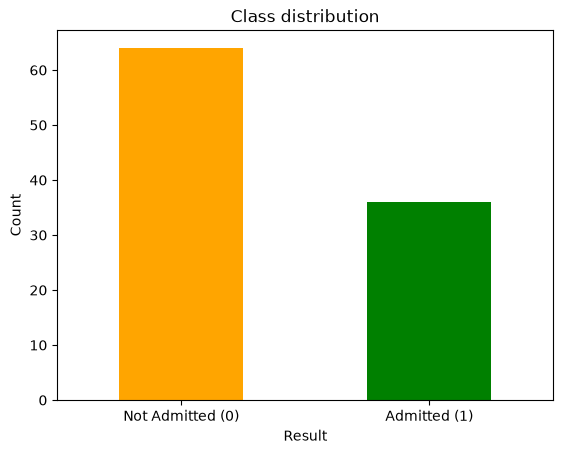

In [8]:
import matplotlib.pyplot as plt

df['Result'].value_counts().plot(kind='bar', color=['orange','green'])
plt.xticks([0,1], ['Not Admitted (0)', 'Admitted (1)'], rotation=0)
plt.title('Class distribution')
plt.ylabel('Count')
plt.show()

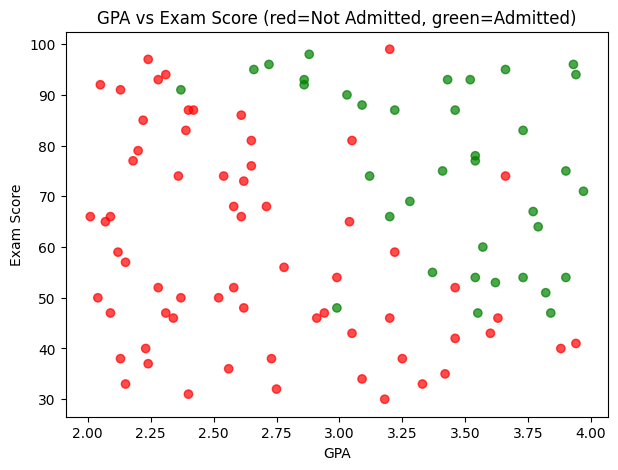

In [8]:
plt.figure(figsize=(7,5))
colors = df['Result'].map({0: 'red', 1: 'green'})
plt.scatter(df['GPA'], df['Exam_Score'], c=colors, alpha=0.7)
plt.xlabel('GPA')
plt.ylabel('Exam Score')
plt.title('GPA vs Exam Score (red=Not Admitted, green=Admitted)')
plt.show()

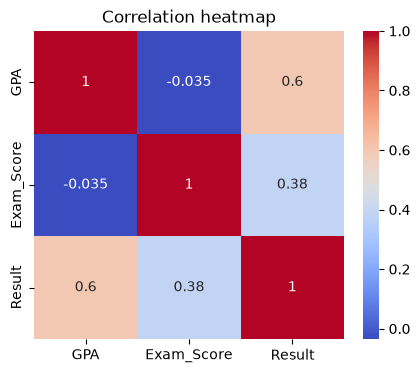

In [9]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

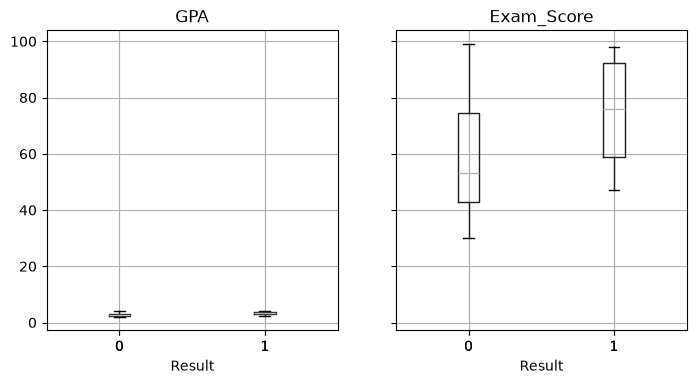

In [10]:
df.boxplot(column=['GPA','Exam_Score'], by='Result', figsize=(8,4))
plt.suptitle('')
plt.show()

## 5. Train-Test Split

We split the data so that the model **learns** on the training set and gets **evaluated** on unseen data (test set).

In [11]:
from sklearn.model_selection import train_test_split

X = df[['GPA', 'Exam_Score']]
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (80, 2)
Test size: (20, 2)


## 6. Apply Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print('Slope (m1 for GPA, m2 for Exam_Score):', model.coef_)
print('Intercept (c):', model.intercept_)

Slope (m1 for GPA, m2 for Exam_Score): [[2.62100765 0.06364047]]
Intercept (c): [-12.84557749]


In [13]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0])

## 7. Model Evaluation: Confusion Matrix, Accuracy, Precision, Recall

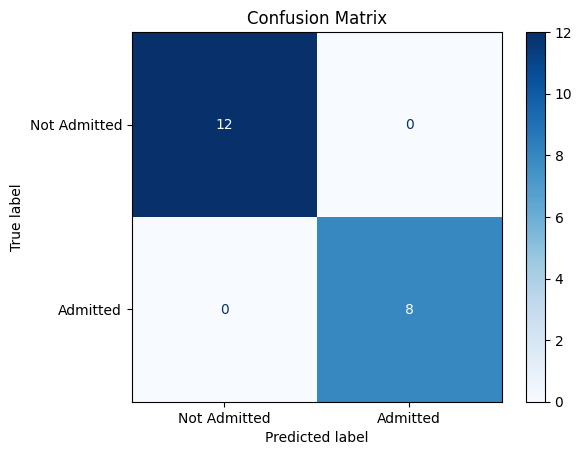

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Admitted','Admitted'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'Accuracy : {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall   : {recall:.2f}')

Accuracy : 1.00
Precision: 1.00
Recall   : 1.00


In [16]:
print(classification_report(y_test, y_pred, target_names=['Not Admitted','Admitted']))

              precision    recall  f1-score   support

Not Admitted       1.00      1.00      1.00        12
    Admitted       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 8. Quick Recap for Students

- `z = m1*GPA + m2*Exam_Score + c` -> passed through sigmoid -> probability `h`
- If `h >= 0.5` -> Admitted (1), else Not Admitted (0)
- `sklearn` finds the best `m1, m2, c` automatically using Gradient Descent internally
- **Accuracy** = overall correctness
- **Precision** = out of predicted Admitted, how many were actually Admitted
- **Recall** = out of actual Admitted, how many did we correctly catch